# PROJET NLP ENSAE — Détection de l'appartenance politique dans les professions de foi (corpus Archelec, 1973-1993)


# Détection de l'appartenance politique dans les professions de foi françaises
## Corpus Archelec — Élections législatives 1973-1993

---

## Contexte et motivation

Ce projet s'inscrit dans le cadre du cours de Natural Language Processing de l'ENSAE. Il porte sur l'analyse automatique des **professions de foi** des candidats aux élections législatives de la Ve République française, issues du corpus **Archelec** constitué et numérisé par Sciences Po (Gaultier-Voituriez, *Archelec, les archives électorales françaises de la Ve République, du papier au numérique*).

Une profession de foi est un document officiel remis par chaque candidat aux électeurs de sa circonscription. Elle constitue un support privilégié d'expression politique : contrairement aux discours ou aux interviews, elle est rédigée librement, sans contrainte journalistique, et reflète directement les choix rhétoriques et thématiques du candidat.

---

## Problématique

Dans quelle mesure le style rhétorique des professions de foi permet-il de prédire l'appartenance politique d'un candidat, indépendamment de toute mention explicite de son parti ?

Pour répondre à cette question, nous conduisons deux expériences parallèles :
- **Expérience 1** : classification sur le texte brut (noms de partis présents)
- **Expérience 2** : classification sur le texte nettoyé (noms de partis supprimés)

La différence de performance entre les deux expériences mesure dans quelle mesure l'appartenance politique est explicitement déclarée plutôt qu'implicitement encodée dans le discours.
---

## Données

Le corpus est constitué de **21 171 professions de foi** numérisées et transcrites par OCR, couvrant cinq élections législatives : 1973, 1978, 1981, 1988 et 1993. Les textes sont issus du dépôt GitLab Teklia (`arkindex_archelec`) et les métadonnées (parti politique, département, profession, sexe, âge du candidat) proviennent du portail Sciences Po Archelec.

---

## Approche

Nous comparons trois approches de classification de complexité croissante :

1. **TF-IDF + Naive Bayes** — baseline statistique
2. **TF-IDF + SVM linéaire** — modèle discriminant adapté aux espaces de grande dimension
3. **CamemBERT** — modèle de langue pré-entraîné sur le français, fine-tuné sur notre corpus

L'évaluation repose sur les métriques de précision, rappel et F1-score par famille politique, ainsi que sur l'analyse des matrices de confusion pour interpréter les erreurs du modèle.

---

## Structure du notebook

| Section | Contenu |
|---|---|
| 1. Chargement des données | Import CSV métadonnées + fichiers texte |
| 2. Analyse exploratoire | Statistiques descriptives, distributions |
| 3. Préprocessing | Nettoyage OCR, construction des labels |
| 4. Modèles | TF-IDF+NB, TF-IDF+SVM, CamemBERT |
| 5. Évaluation | Métriques, matrices de confusion |
| 6. Analyse des résultats | Mots discriminants, projection 2D |

## I Chargement des données | Import CSV métadonnées + fichiers texte
### 1. IMPORTS 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 2. CHARGEMENT DES MÉTADONNÉES

Le fichier archelect_search.csv est exporté depuis le portail Sciences Po Archelec (https://archelec.sciencespo.fr/explorer)
Il contient 21 171 entrées et 42 colonnes pour les élections législatives des années 1973, 1978, 1981, 1988 et 1993.

In [11]:
df = pd.read_csv('../data/external/archelect_search.csv', low_memory=False)
print(f"Dimensions du dataset : {df.shape}")
print(f"Années disponibles : {sorted(pd.to_datetime(df['date']).dt.year.unique())}")

Dimensions du dataset : (21171, 42)
Années disponibles : [np.int32(1973), np.int32(1978), np.int32(1981), np.int32(1988), np.int32(1993)]


### 3. SÉLECTION DES COLONNES PERTINENTES

Pour notre tâche de classification politique, nous retenons :
 - id                  : clé de jointure avec les fichiers texte
 - date                : pour l'analyse temporelle
 - departement-insee   : pour l'analyse géographique
 - contexte-tour       : tour 1 ou 2
 - titulaire-soutien   : LABEL 
 — soutien politique déclaré
 - titulaire-sexe, titulaire-profession, titulaire-age-calcule pour les analyses croisées

In [12]:
cols = ['id', 'date', 'departement-insee', 'contexte-tour',
        'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe',
        'titulaire-age-calcule', 'titulaire-profession',
        'titulaire-soutien']

df = df[cols].copy()
df['year'] = pd.to_datetime(df['date']).dt.year
print(df.shape)
df.head(3)

(21171, 11)


,id,date,departement-insee,contexte-tour,titulaire-nom,titulaire-prenom,titulaire-sexe,titulaire-age-calcule,titulaire-profession,titulaire-soutien,year
0,EL065_L_1973_03_001_01_1_PF_01,1973-03-04,01 - Ain,1,Barberot,Paul,homme,non mentionné,non mentionné,Centre progrès et démocratie moderne;Union des...,1973
1,EL065_L_1973_03_001_01_1_PF_02,1973-03-04,01 - Ain,1,Monnet,Roland,homme,40,ingénieur EDF,Parti socialiste;Mouvement des radicaux de gauche,1973
2,EL065_L_1973_03_001_01_1_PF_03,1973-03-04,01 - Ain,1,Chomarat,Michel,homme,24,cadre technique,non mentionné,1973


# -----------------------------------------------------------
# 4. CONSTRUCTION DES LABELS — APPROCHE PAR SEUIL
# -----------------------------------------------------------
# Plutôt que d'imposer un regroupement manuel subjectif,
# nous adoptons une approche data-driven : nous conservons
# uniquement les partis ayant strictement plus de 100 candidats
# dans le corpus. Ce seuil garantit un volume minimal
# d'exemples pour l'entraînement des modèles.
#
# Les candidats "non mentionné", "indépendant", "sans étiquette"
# sont exclus car ils ne portent pas de signal politique exploitable.

### 4. CONSTRUCTION DES LABELS — APPROCHE PAR SEUIL

Plutôt que d'imposer un regroupement manuel subjectif, nous adoptons une approche data-driven : nous conservons uniquement les partis ayant strictement plus de 50 candidats dans le corpus. Ce seuil garantit un volume minimal d'exemples pour l'entraînement des modèles.

Les candidats "non mentionné", "indépendant", "sans étiquette" sont exclus car ils ne portent pas de signal politique exploitable.

In [22]:
SEUIL = 50

# Exclure les valeurs non informatives
non_informatif = ['non mentionné', 'indépendant', 'sans étiquette', 
                  'libre', 'aucun parti politique']
df_filtered = df[~df['titulaire-soutien'].isin(non_informatif)].copy()

# Calculer les effectifs par parti
effectifs = df_filtered['titulaire-soutien'].value_counts()

# Ne garder que les partis au-dessus du seuil
partis_retenus = effectifs[effectifs >= SEUIL].index
df_model = df_filtered[df_filtered['titulaire-soutien'].isin(partis_retenus)].copy()

print(f"Partis retenus (≥ {SEUIL} candidats) : {len(partis_retenus)}")
print(f"\nDistribution :")
print(df_model['titulaire-soutien'].value_counts())
print(f"\nDocs retenus   : {len(df_model)}")
print(f"Taux de couverture : {len(df_model) / len(df) * 100:.1f}%")

Partis retenus (≥ 50 candidats) : 37

Distribution :
titulaire-soutien
Parti communiste français                                                                                                                       2474
Parti socialiste                                                                                                                                1735
Front national                                                                                                                                  1366
Lutte ouvrière                                                                                                                                  1023
Rassemblement pour la République;Union pour la démocratie française                                                                              764
Rassemblement pour la République                                                                                                                 637
Union pour la démocratie française;

### 5. REGROUPEMENT EN FAMILLES POLITIQUES

Les 37 partis retenus sont regroupés en 6 familles politiques selon le positionnement gauche-droite communément admis pour la Ve République.

In [25]:
mapping_partis = {
    # EXTRÊME GAUCHE
    'Lutte ouvrière'                          : 'Extrême gauche',
    'Ligue communiste révolutionnaire'        : 'Extrême gauche',
    'Ligue communiste'                        : 'Extrême gauche',
    'Parti ouvrier européen'                  : 'Extrême gauche',

    # GAUCHE
    'Parti communiste français'               : 'Gauche',
    'Parti socialiste'                        : 'Gauche',
    'Parti socialiste unifié'                 : 'Gauche',
    'Mouvement des radicaux de gauche'        : 'Gauche',
    'Mouvement des citoyens'                  : 'Gauche',
    'Parti socialiste démocrate'              : 'Gauche',
    'Parti socialiste;Mouvement des radicaux de gauche'                              : 'Gauche',
    'Parti socialiste;Radicaux de gauche'                                            : 'Gauche',
    'Parti communiste français;Parti socialiste;Mouvement des radicaux de gauche'   : 'Gauche',
    'Parti communiste français;Parti socialiste;Radicaux de gauche'                 : 'Gauche',

    # ÉCOLOGISTES
    'Verts;Génération écologie'                                                      : 'Écologistes',
    'Génération écologie;Verts'                                                      : 'Écologistes',
    'Ecologie les Verts;Génération écologie'                                         : 'Écologistes',
    'Nouveaux écologistes du rassemblement nature et animaux'                        : 'Écologistes',
    'Nouveaux écologistes du rassemblement nature et animaux;Union nationale écologiste;Parti pour la défense des animaux;Mouvement universaliste' : 'Écologistes',
    'Parti de la loi naturelle'                                                      : 'Écologistes',

    # CENTRE
    'Union pour la démocratie française'                                             : 'Centre',
    'Mouvement réformateur'                                                          : 'Centre',
    'Mouvement des démocrates'                                                       : 'Centre',
    'Alliance républicaine indépendante et libérale'                                 : 'Centre',
    'Centre national des indépendants et paysans'                                    : 'Centre',

    # DROITE
    'Rassemblement pour la République'                                               : 'Droite',
    'Union des républicains de progrès'                                              : 'Droite',
    'Alliance populaire'                                                             : 'Droite',
    'Rassemblement pour la République;Union pour la démocratie française'            : 'Droite',
    'Union pour la démocratie française;Rassemblement pour la République'            : 'Droite',
    'Union des républicains de progrès;Union des démocrates pour la République;Républicains indépendants;Centre Démocratie et Progrès' : 'Droite',
    'Union des républicains de progrès;Républicains indépendants'                    : 'Droite',
    'Centre national des indépendants et paysans;Rassemblement pour la République;Union pour la démocratie française' : 'Droite',
    'Rassemblement pour la République;Union pour la démocratie française;Centre national des indépendants et paysans' : 'Droite',

    # EXTRÊME DROITE
    'Front national'                                                                 : 'Extrême droite',
    'Parti des forces nouvelles'                                                     : 'Extrême droite',
    'Front national;Centre démocrate et républicain'                                 : 'Extrême droite',
}

df_model['famille_politique'] = df_model['titulaire-soutien'].map(mapping_partis)

print("Distribution finale :")
print(df_model['famille_politique'].value_counts())
print(f"\nDocs classifiés : {df_model['famille_politique'].notna().sum()}")
print(f"Taux de couverture : {df_model['famille_politique'].notna().sum() / len(df) * 100:.1f}%")

Distribution finale :
famille_politique
Gauche            5451
Droite            2495
Extrême droite    1537
Extrême gauche    1411
Écologistes       1031
Centre             689
Name: count, dtype: int64

Docs classifiés : 12614
Taux de couverture : 59.6%


### 6. CHARGEMENT ET FUSION DES TEXTES

In [34]:
from pathlib import Path

DATA_DIR = Path('../data/raw/text_files')

records = []
for filepath in sorted(DATA_DIR.rglob('*.txt')):
    stem = filepath.stem
    parts = stem.rsplit('_', 1)
    if len(parts) != 2 or not parts[1].isdigit():
        continue
    try:
        text = filepath.read_text(encoding='utf-8', errors='replace')
    except:
        continue
    records.append({'id': stem, 'text_raw': text})

df_texts = pd.DataFrame(records)
print(f"Fichiers txt chargés : {len(df_texts)}")

# Fusion avec les métadonnées sur l'id complet
df_final = df_model.merge(df_texts, on='id', how='inner')
print(f"Dataset final        : {df_final.shape}")
print(f"\nDistribution des familles politiques :")
print(df_final['famille_politique'].value_counts())

Fichiers txt chargés : 21171
Dataset final        : (12613, 14)

Distribution des familles politiques :
famille_politique
Gauche            5450
Droite            2495
Extrême droite    1537
Extrême gauche    1411
Écologistes       1031
Centre             689
Name: count, dtype: int64


In [39]:
df_final.head(3)

,id,date,departement-insee,contexte-tour,titulaire-nom,titulaire-prenom,titulaire-sexe,titulaire-age-calcule,titulaire-profession,titulaire-soutien,year,famille_politique,candidate_id,text_raw
0,EL065_L_1973_03_001_01_1_PF_02,1973-03-04,01 - Ain,1,Monnet,Roland,homme,40,ingénieur EDF,Parti socialiste;Mouvement des radicaux de gauche,1973,Gauche,EL065_L_1973_03_001_01_1_PF,REPUBLIQUE FRANCAISE - LIBERTE - EGALITE - FRA...
1,EL065_L_1973_03_001_01_1_PF_04,1973-03-04,01 - Ain,1,Benoit,Marcel,homme,non mentionné,cultivateur,Parti communiste français,1973,Gauche,EL065_L_1973_03_001_01_1_PF,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANÇA...
2,EL065_L_1973_03_001_01_1_PF_07,1973-03-04,01 - Ain,1,Jaquinod,Bernard,homme,non mentionné,inspecteur principal adjoint PTT,Parti socialiste unifié,1973,Gauche,EL065_L_1973_03_001_01_1_PF,Sciences Po / fonds CEVIPOF\nElections Législa...


## II. Analyse exploratoire

### 1. Statistiques descriptives

Nous analysons ici la distribution du corpus selon plusieurs dimensions : la répartition par famille politique, l'évolution temporelle, et la longueur des documents. Ces statistiques permettent de caractériser le corpus et d'anticiper les défis de la modélisation, notamment le déséquilibre des classes.

In [40]:
# Longueur des textes en mots
df_final['n_words'] = df_final['text_raw'].str.split().str.len()

print("Longueur des professions de foi par famille politique (en mots) :")
print(df_final.groupby('famille_politique')['n_words'].describe().round(0))

Longueur des professions de foi par famille politique (en mots) :
                    count    mean    std    min     25%     50%     75%  \
famille_politique                                                         
Centre              689.0   595.0  281.0   70.0   407.0   519.0   743.0   
Droite             2495.0   587.0  316.0   29.0   364.0   508.0   740.0   
Extrême droite     1537.0   810.0  345.0   25.0   500.0   829.0   911.0   
Extrême gauche     1411.0  1220.0  208.0  449.0  1150.0  1232.0  1269.0   
Gauche             5450.0   738.0  307.0   61.0   508.0   711.0   933.0   
Écologistes        1031.0   468.0  266.0  120.0   259.0   415.0   592.0   

                      max  
famille_politique          
Centre             2039.0  
Droite             2516.0  
Extrême droite     2651.0  
Extrême gauche     2259.0  
Gauche             2581.0  
Écologistes        2265.0  


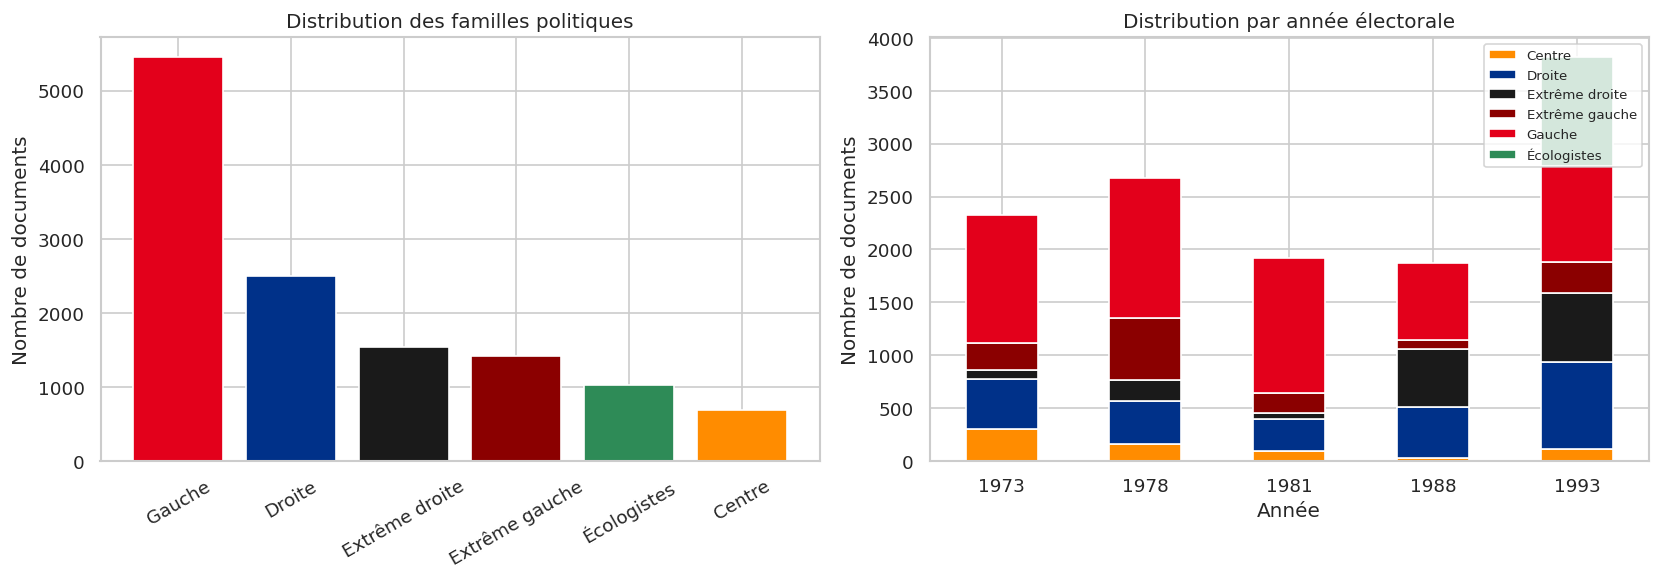

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution par famille politique
counts = df_final['famille_politique'].value_counts()
colors = {
    'Gauche'         : '#E3001B',
    'Extrême gauche' : '#8B0000',
    'Centre'         : '#FF8C00',
    'Droite'         : '#003189',
    'Extrême droite' : '#1A1A1A',
    'Écologistes'    : '#2E8B57'
}
axes[0].bar(counts.index, counts.values,
            color=[colors[x] for x in counts.index])
axes[0].set_title('Distribution des familles politiques')
axes[0].set_ylabel('Nombre de documents')
axes[0].tick_params(axis='x', rotation=30)

# Distribution par année
year_party = df_final.groupby(['year', 'famille_politique']).size().unstack(fill_value=0)
year_party.plot(kind='bar', ax=axes[1],
                color=[colors[c] for c in year_party.columns],
                stacked=True)
axes[1].set_title('Distribution par année électorale')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre de documents')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

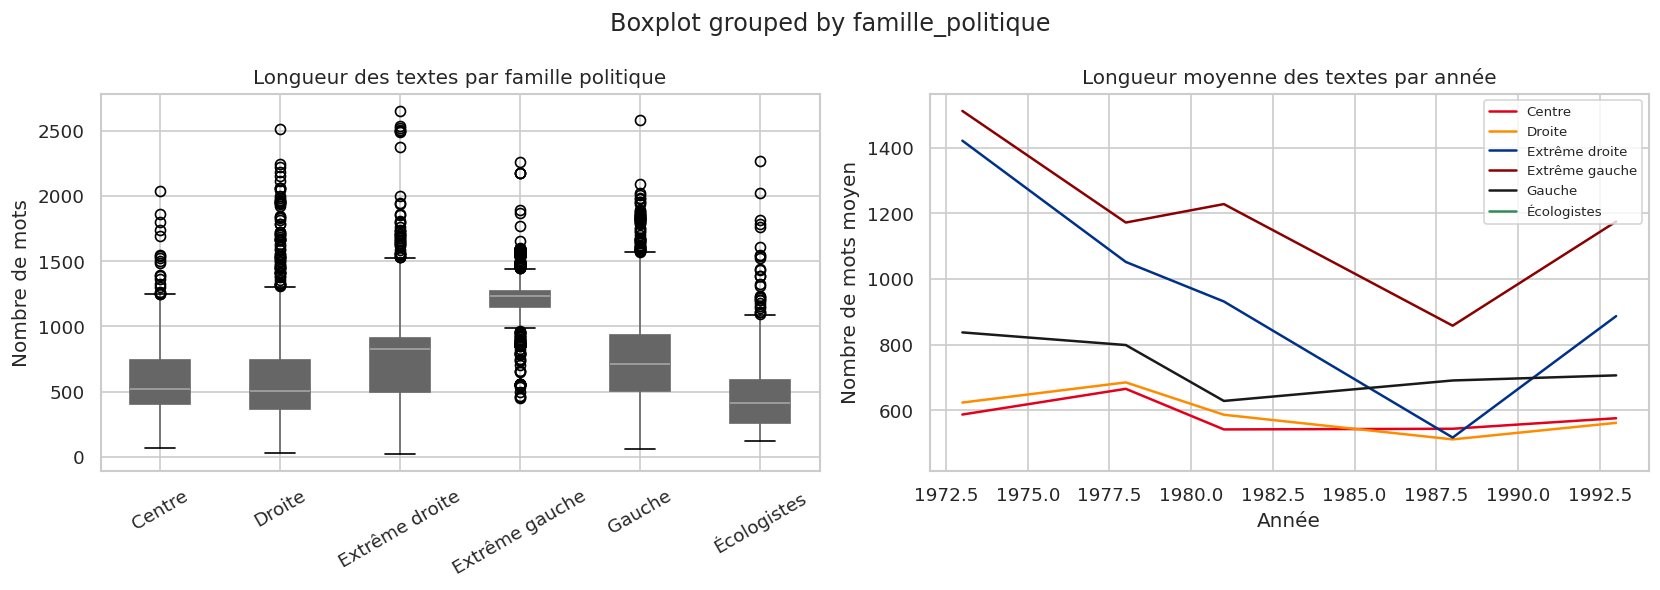

In [42]:
# Longueur des textes par famille politique
df_final['n_words'] = df_final['text_raw'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot longueur par famille
df_final.boxplot(column='n_words', by='famille_politique', ax=axes[0],
                 patch_artist=True)
axes[0].set_title('Longueur des textes par famille politique')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nombre de mots')
axes[0].tick_params(axis='x', rotation=30)

# Evolution longueur moyenne par année
df_final.groupby(['year', 'famille_politique'])['n_words'].mean().unstack().plot(
    ax=axes[1],
    color=[colors[c] for c in df_final['famille_politique'].unique()]
)
axes[1].set_title('Longueur moyenne des textes par année')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Nombre de mots moyen')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2 . Mention explicite du parti dans les textes

Une question cruciale pour la modélisation : les candidats mentionnent-ils explicitement le nom de leur parti dans leur profession de foi ? Si c'est le cas massivement, un modèle pourrait prédire l'appartenance politique en lisant simplement le nom du parti plutôt qu'en apprenant le style rhétorique. Cette observation motive la construction de deux versions du corpus.

In [43]:
# Vérifier combien de textes contiennent explicitement le nom du parti
partis_a_supprimer = list(mapping_partis.keys())

def count_mentions(text, partis):
    text_lower = text.lower()
    return sum(1 for p in partis if p.lower() in text_lower)

df_final['n_mentions_parti'] = df_final['text_raw'].apply(
    lambda x: count_mentions(x, partis_a_supprimer)
)

print(f"Textes avec au moins 1 mention de parti : {(df_final['n_mentions_parti'] > 0).sum()}")
print(f"Soit : {(df_final['n_mentions_parti'] > 0).mean()*100:.1f}% du corpus")
print(f"\nMoyenne de mentions par texte : {df_final['n_mentions_parti'].mean():.1f}")

Textes avec au moins 1 mention de parti : 9958
Soit : 79.0% du corpus

Moyenne de mentions par texte : 1.0


79% des professions de foi contiennent au moins une mention explicite du parti ou du soutien politique du candidat. Ce résultat nous conduit à construire une seconde version du corpus dans laquelle ces mentions sont supprimées, afin de tester si les modèles sont capables d'identifier l'appartenance politique à partir du seul style rhétorique. Nous créons ainsi deux colonnes dans notre dataset : `text_raw` pour l'expérience 1 et `text_no_party` pour l'expérience 2.


In [46]:
import re

partis_a_supprimer_texte = sorted(mapping_partis.keys(), key=len, reverse=True)

def remove_party_names(text):
    for parti in partis_a_supprimer_texte:
        text = re.sub(re.escape(parti), " ", text, flags=re.IGNORECASE)
    text = re.sub(r"Sciences Po\s*/\s*fonds CEVIPOF[^\n]*", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_final['text_no_party'] = df_final['text_raw'].apply(remove_party_names)


In [47]:
df_final['n_mentions_after'] = df_final['text_no_party'].apply(
    lambda x: count_mentions(x, partis_a_supprimer_texte)
)

print(f"AVANT suppression :")
print(f"  Textes avec mention : {(df_final['n_mentions_parti'] > 0).sum()} ({(df_final['n_mentions_parti'] > 0).mean()*100:.1f}%)")

print(f"\nAPRÈS suppression :")
print(f"  Textes avec mention : {(df_final['n_mentions_after'] > 0).sum()} ({(df_final['n_mentions_after'] > 0).mean()*100:.1f}%)")

AVANT suppression :
  Textes avec mention : 9958 (79.0%)

APRÈS suppression :
  Textes avec mention : 27 (0.2%)


## III. Préprocessing NLP

Les professions de foi ont été numérisées par OCR (Optical Character Recognition) à partir de documents papier des années 1973-1993. Ce processus introduit des artefacts typiques : caractères mal reconnus, watermarks répétés ("Sciences Po / fonds CEVIPOF"), cases à cocher (☐☒), et espaces multiples. Nous appliquons un pipeline de nettoyage en deux étapes : d'abord la suppression de ces artefacts OCR, puis une lemmatisation avec spaCy qui réduit les formes fléchies à leur forme canonique et supprime les stopwords (mots grammaticaux sans contenu sémantique comme "le", "de", "et"). Ce pipeline est appliqué aux deux versions du texte : `text_raw` et `text_no_party`.

### 1. Nettoyage et lemmatisation

In [51]:
import spacy
nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])

def lemmatize_batch(texts):
    return [
        " ".join([token.lemma_ for token in doc 
                  if not token.is_stop and len(token.text) > 2])
        for doc in nlp.pipe(texts, batch_size=50)
    ]

print("Preprocessing text_raw...")
df_final['text_processed'] = lemmatize_batch(
    df_final['text_raw'].str.lower().str.replace(r"[^a-zàâäéèêëîïôùûüç\s]", " ", regex=True)
)

print("Preprocessing text_no_party...")
df_final['text_no_party_processed'] = lemmatize_batch(
    df_final['text_no_party'].str.lower().str.replace(r"[^a-zàâäéèêëîïôùûüç\s]", " ", regex=True)
)

print("Terminé !")

Preprocessing text_raw...
Preprocessing text_no_party...
Terminé !
